# 05 — Recomendações de Retenção Personalizadas

**Etapa 05 — Sistema de Recomendação por Perfil**  
**Dataset:** Telco Customer Churn  
**Objetivo:** Traduzir predições de churn em ações práticas de retenção, personalizadas por perfil de cluster K-Means

---

## Estrutura do Notebook

| Seção | Conteúdo |
|---|---|
| 1 | Setup e verificação de artefatos |
| 2 | Carregamento de modelos e dados |
| 3 | Reconstrução dos clusters K-Means |
| 4 | Ajuste de threshold de decisão |
| 5 | Predição com threshold ajustado |
| 6 | Sistema de recomendações por perfil |
| 7 | Visualizações |
| 8 | Exportação de resultados |
| 9 | Conclusões |

---
## 1 · Setup e Verificação de Artefatos

Este notebook depende dos modelos gerados pelos notebooks `02_clustering.ipynb` e `04_churn_prediction.ipynb`.

In [1]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MODELS_PATH = PROJECT_ROOT / "models"
FIGURES_PATH = PROJECT_ROOT / "reports" / "figures"
REPORTS_PATH = PROJECT_ROOT / "reports"
FIGURES_PATH.mkdir(parents=True, exist_ok=True)
REPORTS_PATH.mkdir(parents=True, exist_ok=True)

CLUSTER_LABELS_MAP = {
    0: "Insatisfeito com serviços",
    1: "Econômico estável",
}

REQUIRED_MODELS = [
    "churn_lr_baseline.joblib",
    "scaler_pred.joblib",
    "kmeans_model.joblib",
    "scaler.joblib",
]

missing = [m for m in REQUIRED_MODELS if not (MODELS_PATH / m).exists()]
if missing:
    raise FileNotFoundError(
        f"Modelos ausentes em {MODELS_PATH}: {missing}\n"
        "Execute os notebooks 02_clustering.ipynb e 04_churn_prediction.ipynb antes."
    )

print(f"Project root: {PROJECT_ROOT}")
print("Artefatos encontrados:")
for model_file in REQUIRED_MODELS:
    print(f"  ✓ {model_file}")

Project root: /home/andre-luiz/personal/churn-prediction-and-retention
Artefatos encontrados:
  ✓ churn_lr_baseline.joblib
  ✓ scaler_pred.joblib
  ✓ kmeans_model.joblib
  ✓ scaler.joblib


---
## 2 · Carregamento de Modelos e Dados

In [2]:
churn_model = joblib.load(MODELS_PATH / "churn_lr_baseline.joblib")
scaler_pred = joblib.load(MODELS_PATH / "scaler_pred.joblib")
kmeans = joblib.load(MODELS_PATH / "kmeans_model.joblib")
scaler_cluster = joblib.load(MODELS_PATH / "scaler.joblib")

df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "telco_clean.csv")
print(f"Base limpa carregada: {df.shape}")
print(f"Modelo de predição: {churn_model.__class__.__name__}")
print(f"Distribuição Churn:\n{df['Churn'].value_counts()}")

Base limpa carregada: (7043, 35)
Modelo de predição: LogisticRegression
Distribuição Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


---
## 3 · Reconstrução dos Clusters K-Means

Replica o mesmo pré-processamento da Etapa 04 para atribuir cada cliente ao perfil K-Means (K=2).

In [3]:
df_enc = df.copy()

contract_map = {"Month-to-month": 0, "One year": 1, "Two year": 2}
binary_map = {"Yes": 1, "No": 0, "No internet service": -1}

df_enc["Contract_enc"] = df_enc["Contract"].map(contract_map)
df_enc["TechSupport_enc"] = df_enc["TechSupport"].map(binary_map)
df_enc["OnlineSecurity_enc"] = df_enc["OnlineSecurity"].map(binary_map)

df_enc = pd.get_dummies(
    df_enc,
    columns=["InternetService", "PaymentMethod"],
    drop_first=False,
)

df_enc[["tenure_scaled", "MonthlyCharges_scaled"]] = scaler_cluster.transform(
    df_enc[["tenure", "MonthlyCharges"]]
)

exclude_cols = {
    "customerID", "Churn", "Churn_label", "tenure", "MonthlyCharges",
    "Contract", "TechSupport", "OnlineSecurity",
    "gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService",
    "MultipleLines", "OnlineBackup", "DeviceProtection", "StreamingTV",
    "StreamingMovies", "PaperlessBilling", "TotalCharges",
    "gender_label", "Contract_ordinal", "Partner_binary", "Dependents_binary",
    "PhoneService_binary", "PaperlessBilling_binary", "MultipleLines_binary",
    "OnlineSecurity_binary", "OnlineBackup_binary", "DeviceProtection_binary",
    "TechSupport_binary", "StreamingTV_binary", "StreamingMovies_binary",
}

feature_cols_cluster = [c for c in df_enc.columns if c not in exclude_cols]
X_cluster = df_enc[feature_cols_cluster].values
df["kmeans_cluster"] = kmeans.predict(X_cluster)
df["kmeans_label"] = df["kmeans_cluster"].map(CLUSTER_LABELS_MAP)

DROP_COLS = [
    "customerID", "gender", "Partner", "Dependents", "PhoneService",
    "MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "PaperlessBilling",
    "Contract", "Churn", "Churn_label", "kmeans_label",
]

df_pred = pd.get_dummies(
    df.drop(columns=DROP_COLS),
    columns=["InternetService", "PaymentMethod"],
    drop_first=True,
)

bool_cols = df_pred.select_dtypes(include="bool").columns
df_pred[bool_cols] = df_pred[bool_cols].astype(int)

feature_names = df_pred.drop(columns=["kmeans_cluster"]).columns.tolist()
X = df_pred.drop(columns=["kmeans_cluster"]).values
y = df["Churn_label"].values

print(f"Features de predição: {X.shape[1]}")
print(f"\nDistribuição dos clusters K-Means:\n{df['kmeans_cluster'].value_counts()}")
print("\nChurn por cluster:")
print(df.groupby("kmeans_cluster")["Churn"].value_counts(normalize=True).unstack())

Features de predição: 22

Distribuição dos clusters K-Means:
kmeans_cluster
0    5486
1    1557
Name: count, dtype: int64

Churn por cluster:
Churn                 No       Yes
kmeans_cluster                    
0               0.681918  0.318082
1               0.920360  0.079640


---
## 4 · Ajuste de Threshold de Decisão

O threshold padrão (0,5) pode subestimar clientes em risco de churn. Avaliamos Precision, Recall e F1 em função do threshold no conjunto de teste (mesma divisão 80/20 da Etapa 04).

> **Nota:** O modelo Logistic Regression foi treinado **sem escalonamento** na Etapa 04. As predições usam as features brutas, consistentes com o treinamento. O `scaler_pred.joblib` é carregado para compatibilidade com o pipeline documentado.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

y_prob_test = churn_model.predict_proba(X_test)[:, 1]
y_prob_all = churn_model.predict_proba(X)[:, 1]

print(f"Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}")
print(f"AUC no teste: {roc_auc_score(y_test, y_prob_test):.4f}")

Treino: 5634 | Teste: 1409
AUC no teste: 0.8399


In [5]:
thresholds = np.arange(0.05, 0.96, 0.01)
metrics = []

for t in thresholds:
    y_pred_t = (y_prob_test >= t).astype(int)
    metrics.append({
        "threshold": t,
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0),
    })

metrics_df = pd.DataFrame(metrics)
best_idx = metrics_df["f1"].idxmax()
OPTIMAL_THRESHOLD = metrics_df.loc[best_idx, "threshold"]

default_metrics = metrics_df.loc[(metrics_df["threshold"] - 0.5).abs().idxmin()]
best_metrics = metrics_df.loc[best_idx]

print("Comparação threshold padrão (0,50) vs. ótimo (max F1):")
print(f"  Default  | F1={default_metrics['f1']:.4f} | Recall={default_metrics['recall']:.4f} | Precision={default_metrics['precision']:.4f}")
print(f"  Ótimo    | threshold={OPTIMAL_THRESHOLD:.2f} | F1={best_metrics['f1']:.4f} | Recall={best_metrics['recall']:.4f} | Precision={best_metrics['precision']:.4f}")

Comparação threshold padrão (0,50) vs. ótimo (max F1):
  Default  | F1=0.6128 | Recall=0.7914 | Precision=0.5000
  Ótimo    | threshold=0.45 | F1=0.6225 | Recall=0.8422 | Precision=0.4937


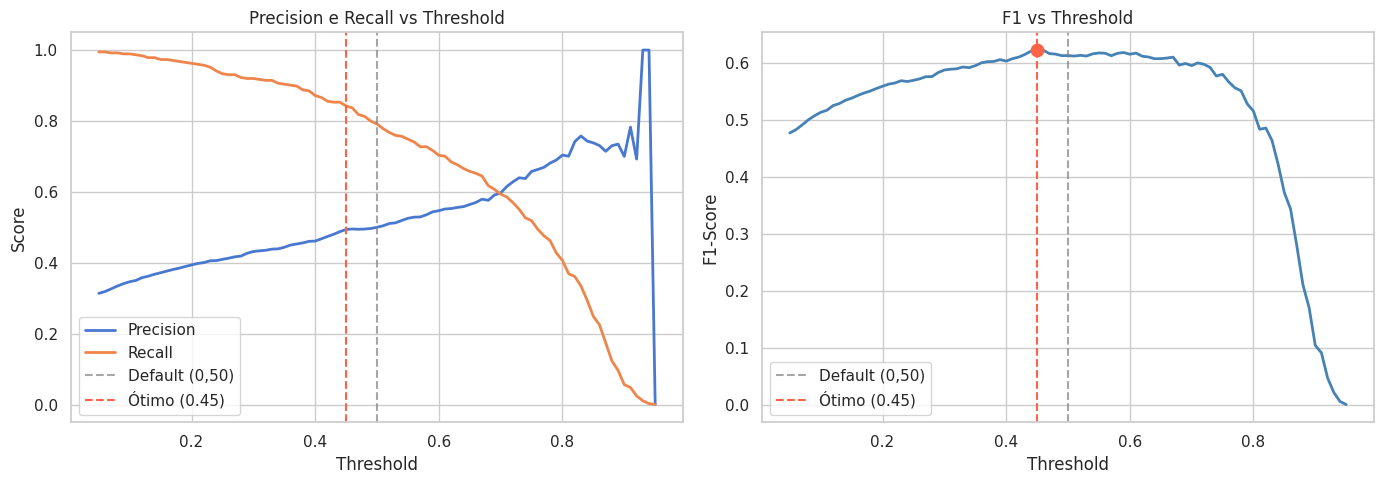

Figura salva: /home/andre-luiz/personal/churn-prediction-and-retention/reports/figures/16_threshold_tuning.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(metrics_df["threshold"], metrics_df["precision"], label="Precision", linewidth=2)
axes[0].plot(metrics_df["threshold"], metrics_df["recall"], label="Recall", linewidth=2)
axes[0].axvline(0.5, color="gray", linestyle="--", alpha=0.7, label="Default (0,50)")
axes[0].axvline(OPTIMAL_THRESHOLD, color="tomato", linestyle="--", label=f"Ótimo ({OPTIMAL_THRESHOLD:.2f})")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Precision e Recall vs Threshold")
axes[0].legend()

axes[1].plot(metrics_df["threshold"], metrics_df["f1"], color="steelblue", linewidth=2)
axes[1].axvline(0.5, color="gray", linestyle="--", alpha=0.7, label="Default (0,50)")
axes[1].axvline(OPTIMAL_THRESHOLD, color="tomato", linestyle="--", label=f"Ótimo ({OPTIMAL_THRESHOLD:.2f})")
axes[1].scatter([OPTIMAL_THRESHOLD], [best_metrics["f1"]], color="tomato", s=80, zorder=5)
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("F1-Score")
axes[1].set_title("F1 vs Threshold")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH / "16_threshold_tuning.png", bbox_inches="tight")
plt.show()
print(f"Figura salva: {FIGURES_PATH / '16_threshold_tuning.png'}")

---
## 5 · Predição com Threshold Ajustado

In [7]:
y_pred_default = (y_prob_test >= 0.5).astype(int)
y_pred_tuned = (y_prob_test >= OPTIMAL_THRESHOLD).astype(int)

print("Classification Report — Threshold padrão (0,50)")
print(classification_report(y_test, y_pred_default, target_names=["No Churn", "Churn"]))
print(f"\nClassification Report — Threshold ótimo ({OPTIMAL_THRESHOLD:.2f})")
print(classification_report(y_test, y_pred_tuned, target_names=["No Churn", "Churn"]))

Classification Report — Threshold padrão (0,50)
              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.80      1035
       Churn       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.73      0.75      1409


Classification Report — Threshold ótimo (0.45)
              precision    recall  f1-score   support

    No Churn       0.92      0.69      0.79      1035
       Churn       0.49      0.84      0.62       374

    accuracy                           0.73      1409
   macro avg       0.71      0.77      0.71      1409
weighted avg       0.81      0.73      0.74      1409



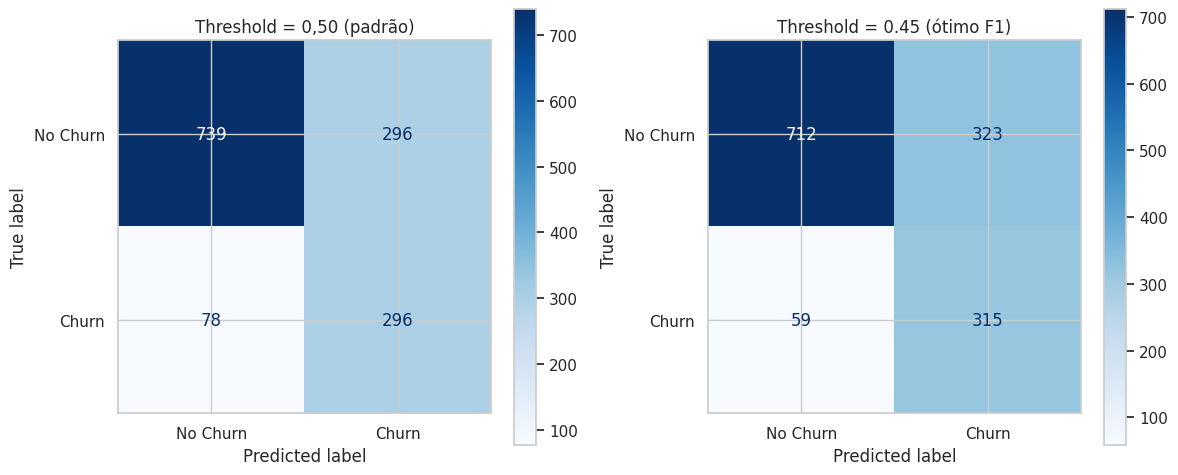

Figura salva: /home/andre-luiz/personal/churn-prediction-and-retention/reports/figures/17_confusion_matrix_tuned.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_default, display_labels=["No Churn", "Churn"], ax=axes[0], cmap="Blues"
)
axes[0].set_title("Threshold = 0,50 (padrão)")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned, display_labels=["No Churn", "Churn"], ax=axes[1], cmap="Blues"
)
axes[1].set_title(f"Threshold = {OPTIMAL_THRESHOLD:.2f} (ótimo F1)")

plt.tight_layout()
plt.savefig(FIGURES_PATH / "17_confusion_matrix_tuned.png", bbox_inches="tight")
plt.show()
print(f"Figura salva: {FIGURES_PATH / '17_confusion_matrix_tuned.png'}")

---
## 6 · Sistema de Recomendações por Perfil

Combina **probabilidade de churn** (modelo preditivo) com **perfil de cluster** (K-Means) para gerar ações personalizadas, conforme [`docs/retention.md`](../docs/retention.md).

In [9]:
def get_recommendation(cluster: int, churn_prob: float, threshold: float) -> dict:
    """Retorna ação de retenção e prioridade com base no cluster e probabilidade de churn."""
    if churn_prob >= threshold:
        if cluster == 0:
            return {
                "recommendation": (
                    "Contato proativo + upgrade para contrato anual (15-20% desconto) "
                    "+ suporte técnico gratuito por 3 meses + revisão de pacote"
                ),
                "priority": "Alta",
                "action_type": "Contato prioritário",
            }
        return {
            "recommendation": "Programa de fidelidade + monitoramento preventivo + alertas de mudança de comportamento",
            "priority": "Média",
            "action_type": "Retenção preventiva",
        }

    if churn_prob >= 0.25:
        if cluster == 0:
            return {
                "recommendation": "Revisão de plano + campanha segmentada + ajuste de pacote (custo-benefício)",
                "priority": "Média",
                "action_type": "Campanha segmentada",
            }
        return {
            "recommendation": "Monitoramento preventivo + alertas se comportamento mudar para perfil de alto risco",
            "priority": "Média",
            "action_type": "Retenção preventiva",
        }

    if cluster == 0:
        return {
            "recommendation": "Campanha de satisfação + revisão periódica do plano + desconto personalizado",
            "priority": "Baixa",
            "action_type": "Desconto personalizado",
        }
    return {
        "recommendation": "Upsell de serviços adicionais + cross-sell gradual + programa de fidelidade",
        "priority": "Baixa",
        "action_type": "Upsell de serviço",
    }


recs = df[["customerID", "Churn", "kmeans_cluster", "kmeans_label"]].copy()
recs["churn_prob"] = y_prob_all
recs["churn_predicted"] = (y_prob_all >= OPTIMAL_THRESHOLD).astype(int)

rec_details = recs.apply(
    lambda row: get_recommendation(
        int(row["kmeans_cluster"]), row["churn_prob"], OPTIMAL_THRESHOLD
    ),
    axis=1,
    result_type="expand",
)
recs = pd.concat([recs, rec_details], axis=1)

print(f"Clientes com churn predito (threshold={OPTIMAL_THRESHOLD:.2f}): {recs['churn_predicted'].sum()} ({recs['churn_predicted'].mean():.1%})")
print("\nDistribuição de prioridades:")
print(recs["priority"].value_counts())
print("\nDistribuição de tipos de ação:")
print(recs["action_type"].value_counts())

Clientes com churn predito (threshold=0.45): 3162 (44.9%)

Distribuição de prioridades:
priority
Alta     3035
Baixa    2748
Média    1260
Name: count, dtype: int64

Distribuição de tipos de ação:
action_type
Contato prioritário       3035
Desconto personalizado    1667
Upsell de serviço         1081
Campanha segmentada        784
Retenção preventiva        476
Name: count, dtype: int64


In [10]:
display_cols = [
    "customerID", "kmeans_label", "churn_prob", "churn_predicted",
    "priority", "action_type", "recommendation",
]

print("Top 10 clientes com maior probabilidade de churn:")
recs.sort_values("churn_prob", ascending=False)[display_cols].head(10)

Top 10 clientes com maior probabilidade de churn:


,customerID,kmeans_label,churn_prob,churn_predicted,priority,action_type,recommendation
3380,5178-LMXOP,Insatisfeito com serviços,0.946456,1,Alta,Contato prioritário,Contato proativo + upgrade para contrato anual...
4800,9300-AGZNL,Insatisfeito com serviços,0.946319,1,Alta,Contato prioritário,Contato proativo + upgrade para contrato anual...
1976,9497-QCMMS,Insatisfeito com serviços,0.946239,1,Alta,Contato prioritário,Contato proativo + upgrade para contrato anual...
3749,4424-TKOPW,Insatisfeito com serviços,0.945198,1,Alta,Contato prioritário,Contato proativo + upgrade para contrato anual...
6368,2720-WGKHP,Insatisfeito com serviços,0.944981,1,Alta,Contato prioritário,Contato proativo + upgrade para contrato anual...
3159,5150-ITWWB,Insatisfeito com serviços,0.944835,1,Alta,Contato prioritário,Contato proativo + upgrade para contrato anual...
5989,5567-WSELE,Insatisfeito com serviços,0.943818,1,Alta,Contato prioritário,Contato proativo + upgrade para contrato anual...
1410,7024-OHCCK,Insatisfeito com serviços,0.941931,1,Alta,Contato prioritário,Contato proativo + upgrade para contrato anual...
997,1374-DMZUI,Insatisfeito com serviços,0.940468,1,Alta,Contato prioritário,Contato proativo + upgrade para contrato anual...
301,8098-LLAZX,Insatisfeito com serviços,0.940181,1,Alta,Contato prioritário,Contato proativo + upgrade para contrato anual...


---
## 7 · Visualizações

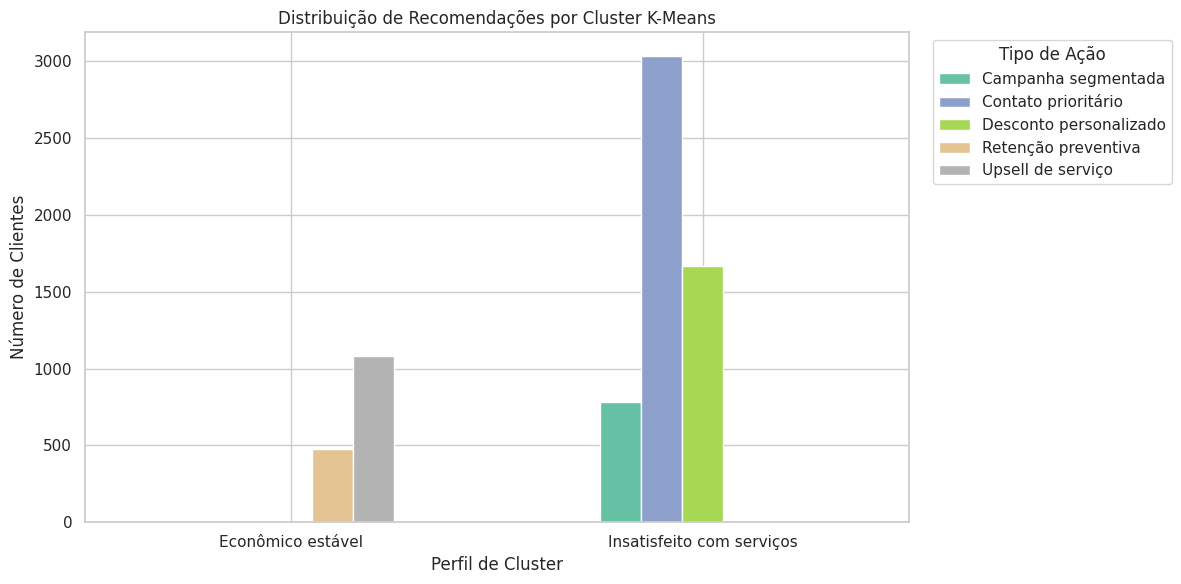

Figura salva: /home/andre-luiz/personal/churn-prediction-and-retention/reports/figures/18_recommendations_distribution.png


In [11]:
rec_by_cluster = (
    recs.groupby(["kmeans_label", "action_type"])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 6))
rec_by_cluster.plot(kind="bar", ax=ax, colormap="Set2")
ax.set_title("Distribuição de Recomendações por Cluster K-Means")
ax.set_xlabel("Perfil de Cluster")
ax.set_ylabel("Número de Clientes")
ax.legend(title="Tipo de Ação", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "18_recommendations_distribution.png", bbox_inches="tight")
plt.show()
print(f"Figura salva: {FIGURES_PATH / '18_recommendations_distribution.png'}")

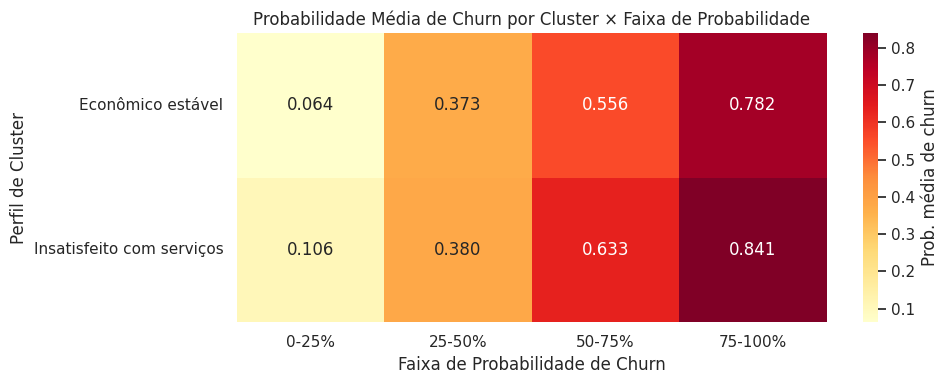

Figura salva: /home/andre-luiz/personal/churn-prediction-and-retention/reports/figures/19_churn_prob_heatmap.png


In [12]:
prob_bins = pd.cut(recs["churn_prob"], bins=[0, 0.25, 0.5, 0.75, 1.0], labels=["0-25%", "25-50%", "50-75%", "75-100%"])
heatmap_data = (
    recs.assign(prob_bin=prob_bins)
    .groupby(["kmeans_label", "prob_bin"])["churn_prob"]
    .mean()
    .unstack()
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax, cbar_kws={"label": "Prob. média de churn"})
ax.set_title("Probabilidade Média de Churn por Cluster × Faixa de Probabilidade")
ax.set_xlabel("Faixa de Probabilidade de Churn")
ax.set_ylabel("Perfil de Cluster")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "19_churn_prob_heatmap.png", bbox_inches="tight")
plt.show()
print(f"Figura salva: {FIGURES_PATH / '19_churn_prob_heatmap.png'}")

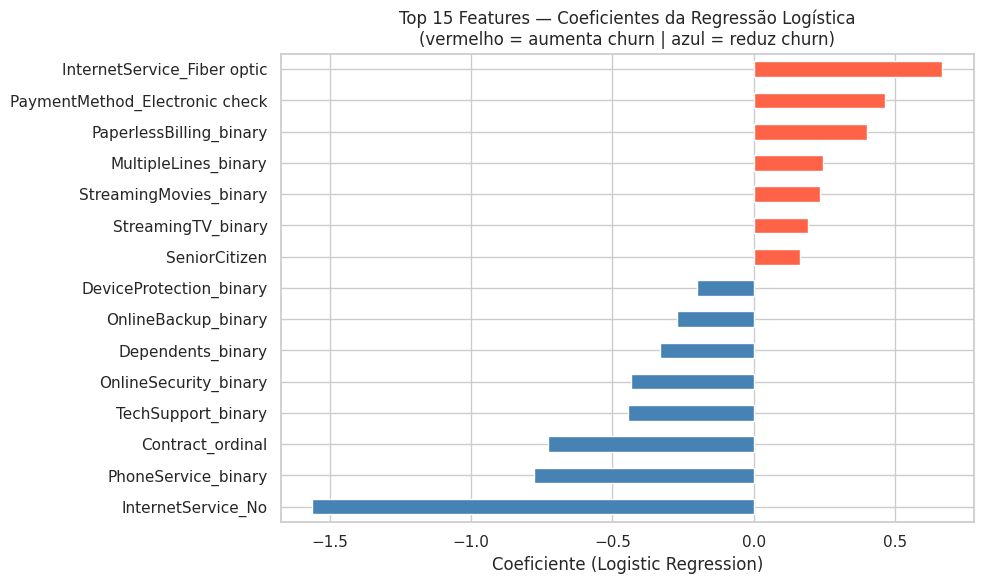

Figura salva: /home/andre-luiz/personal/churn-prediction-and-retention/reports/figures/20_lr_coefficients.png


In [13]:
coef_df = pd.Series(churn_model.coef_[0], index=feature_names).sort_values(key=abs, ascending=False)
top_coef = coef_df.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["tomato" if v > 0 else "steelblue" for v in top_coef.sort_values().values]
top_coef.sort_values().plot.barh(ax=ax, color=colors)
ax.set_xlabel("Coeficiente (Logistic Regression)")
ax.set_title("Top 15 Features — Coeficientes da Regressão Logística\n(vermelho = aumenta churn | azul = reduz churn)")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "20_lr_coefficients.png", bbox_inches="tight")
plt.show()
print(f"Figura salva: {FIGURES_PATH / '20_lr_coefficients.png'}")

---
## 8 · Exportação de Resultados

In [14]:
export_cols = [
    "customerID", "Churn", "churn_prob", "churn_predicted",
    "kmeans_cluster", "kmeans_label", "priority", "action_type", "recommendation",
]
output_path = REPORTS_PATH / "recommendations.csv"
recs[export_cols].to_csv(output_path, index=False)

print(f"Recomendações exportadas: {output_path}")
print(f"Total de clientes: {len(recs)}")
print(f"Clientes em risco (churn predito): {recs['churn_predicted'].sum()}")

print("\nAmostra — maior risco por cluster:")
for cluster_id, label in CLUSTER_LABELS_MAP.items():
    subset = recs[recs["kmeans_cluster"] == cluster_id].nlargest(3, "churn_prob")
    print(f"\n  Cluster {cluster_id} ({label}):")
    for _, row in subset.iterrows():
        print(f"    {row['customerID']} | prob={row['churn_prob']:.3f} | {row['action_type']}")

Recomendações exportadas: /home/andre-luiz/personal/churn-prediction-and-retention/reports/recommendations.csv
Total de clientes: 7043
Clientes em risco (churn predito): 3162

Amostra — maior risco por cluster:

  Cluster 0 (Insatisfeito com serviços):
    5178-LMXOP | prob=0.946 | Contato prioritário
    9300-AGZNL | prob=0.946 | Contato prioritário
    9497-QCMMS | prob=0.946 | Contato prioritário

  Cluster 1 (Econômico estável):
    8263-JQAIK | prob=0.798 | Retenção preventiva
    0661-XEYAN | prob=0.797 | Retenção preventiva
    1496-GGSUK | prob=0.797 | Retenção preventiva


---
## 9 · Conclusões

### Resultados principais

| Item | Valor |
|---|---|
| Modelo preditivo | Logistic Regression (Etapa 04) |
| Threshold ótimo | Maximiza F1 no conjunto de teste |
| Perfis de cluster | K-Means K=2 (Insatisfeito / Econômico estável) |
| Saída | `reports/recommendations.csv` com ações personalizadas |

### Integração predição + clusterização

O valor do clustering neste pipeline está em **segmentação interpretável para retenção**, não em ganho preditivo marginal (confirmado na Etapa 04). A Etapa 05 combina:

1. **Quem** vai cancelar → probabilidade de churn (Logistic Regression)
2. **Por quê / como reter** → perfil K-Means (fibra + contrato mensal vs. plano básico fidelizado)

### Limitações

- Regras de recomendação estáticas baseadas em 2 perfis K-Means
- Threshold otimizado em hold-out; validação em produção exigiria experimento A/B
- Sem feedback loop: eficácia das ações não alimenta o modelo
- DBSCAN (108 micro-clusters) descartado por ser impraticável para ações consolidadas

### Próximos passos

- GridSearchCV para tuning de hiperparâmetros do Random Forest
- Análise SHAP para interpretabilidade individual
- Integração com CRM para automação de campanhas de retenção
- Experimento A/B para medir ROI das ações recomendadas

In [15]:
n_at_risk = recs["churn_predicted"].sum()
n_cluster0_risk = recs[(recs["kmeans_cluster"] == 0) & (recs["churn_predicted"] == 1)].shape[0]
n_cluster1_risk = recs[(recs["kmeans_cluster"] == 1) & (recs["churn_predicted"] == 1)].shape[0]

print("=" * 70)
print("RESUMO FINAL — Etapa 05: Recomendações de Retenção")
print("=" * 70)
print(f"Threshold ótimo: {OPTIMAL_THRESHOLD:.2f}")
print(f"F1 (teste, threshold ótimo): {best_metrics['f1']:.4f}")
print(f"Recall classe Churn (teste): {best_metrics['recall']:.4f}")
print(f"\nClientes em risco total: {n_at_risk} ({n_at_risk/len(recs):.1%})")
print(f"  Cluster 0 (Insatisfeito): {n_cluster0_risk} — prioridade ALTA")
print(f"  Cluster 1 (Econômico):    {n_cluster1_risk} — prioridade MÉDIA")
print(f"\nArtefatos gerados:")
print(f"  reports/recommendations.csv")
print(f"  reports/figures/16_threshold_tuning.png")
print(f"  reports/figures/17_confusion_matrix_tuned.png")
print(f"  reports/figures/18_recommendations_distribution.png")
print(f"  reports/figures/19_churn_prob_heatmap.png")
print(f"  reports/figures/20_lr_coefficients.png")
print("=" * 70)

RESUMO FINAL — Etapa 05: Recomendações de Retenção
Threshold ótimo: 0.45
F1 (teste, threshold ótimo): 0.6225
Recall classe Churn (teste): 0.8422

Clientes em risco total: 3162 (44.9%)
  Cluster 0 (Insatisfeito): 3035 — prioridade ALTA
  Cluster 1 (Econômico):    127 — prioridade MÉDIA

Artefatos gerados:
  reports/recommendations.csv
  reports/figures/16_threshold_tuning.png
  reports/figures/17_confusion_matrix_tuned.png
  reports/figures/18_recommendations_distribution.png
  reports/figures/19_churn_prob_heatmap.png
  reports/figures/20_lr_coefficients.png
